# Linear regression
In this assignment you will implement the linear regression. You need to implement the cost functions, derivative calculation and weight updates and regression functions. Please follow the #TODO to find out what to implement. You are not supposed to use any **sklearn** function for this assignment.

Data reading and processing and some basic visualization is already provided

In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns
from matplotlib import pyplot as plt
import matplotlib.axes as ax
from IPython.display import clear_output

In [3]:
#data reading
df = pd.read_csv("data_for_lr.csv")
df.head()

# Drop null values
df = df.dropna()
df.head()

,x,y
0,24.0,21.549452
1,50.0,47.464463
2,15.0,17.218656
3,38.0,36.586398
4,87.0,87.288984


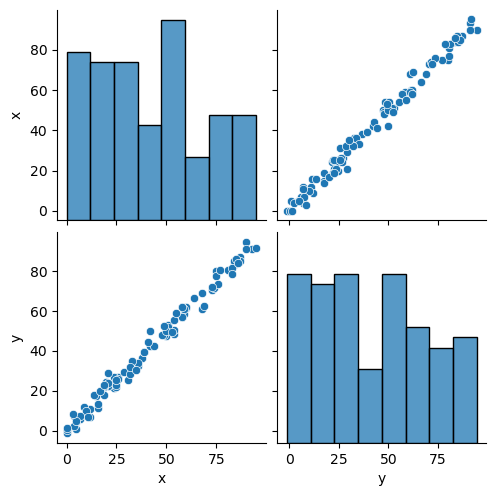

In [4]:
#ploting some data
sns.pairplot(
    df[:100]
)

# Train-Test Split

In [5]:

N = len(df)
training_data_len = int (N*0.8)
x_train, y_train = np.array(df['x'][0:training_data_len]).reshape(training_data_len, 1), np.array(df['y'][0:training_data_len]).reshape(
    training_data_len, 1
)
x_test, y_test = np.array(df['x'][training_data_len:N]).reshape(N - training_data_len, 1), np.array(
    df['y'][training_data_len:N]).reshape(N - training_data_len, 1)

In [44]:
N

699

## linear regression

In [6]:
class LinearRegression:
    def __init__(self):
        self.Q0 = np.random.uniform(0, 1) * -1  # Intercept
        self.Q1 = np.random.uniform(0, 1) * -1  # Coefficient of X
        self.losses = []  # Storing the loss of each iteration
        self.r2s = []  # Storing the r2s of each iteration

    def forward_propogation(self, training_input):
        predicted_values =  self.Q0 + self.Q1 * training_input
        return predicted_values

    def cost(self, predictions, training_output):
        #calculate lmse and r2 score and return them
        n = len(training_output)

        lmse = (1 / (2 * n)) * np.sum((predictions - training_output) ** 2)
    
    
        sse = np.sum((training_output - predictions) ** 2)
        sst = np.sum((training_output - np.mean(training_output)) ** 2)
        r2_score = 1 - (sse / sst) if sst != 0 else 0.0
    
        return lmse, r2_score

    def finding_derivatives(self, cost, predictions, training_input, training_output):
        ##TODO: calculate derivatives of the loss function w.r.t Q0 and Q1
        # d(J(Q0, Q1))/d(Q0) and d(J(Q0, Q1))/d(Q1)

        n = len(training_output)
        errors = predictions - training_output

        
        dQ0 = (1 / n) * np.sum(errors)                 
        dQ1 = (1 / n) * np.sum(errors * training_input) 

        return dQ0, dQ1

    def train(self, x_train, y_train, lr, itrs):
        
        for i in range(itrs):#iterate for # of iteration
            # #TODO: Find the predicted values (Using the linear equation y=mx+c). You can use the forward_propagation function call here
            predictions = self.forward_propogation(x_train)
            # #TODO: Calculating the Loss. Call the cost function
            lmse, r2_score = self.cost(predictions, y_train)
            # #TODO: Store the loss for current iteration at specific arrays
            self.losses.append(lmse)
            self.r2s.append(r2_score)

            # #TODO:Back Propagation (Finding Derivatives of Weights). call finding_derivatives function
            dQ0, dQ1 = self.finding_derivatives(lmse, predictions, x_train, y_train)

            # #TODO: Updating the Weights
            self.Q0 = self.Q0 - lr * dQ0
            self.Q1 = self.Q1 - lr * dQ1

            # Following is the code for plotting. No changes are required.
            # It will dynamically update the plot of the straight line
            line = self.Q0 + x_train * self.Q1
            clear_output(wait=True)
            plt.plot(x_train, y_train, "+", label="Actual values")
            plt.plot(x_train, line, label="Linear Equation")
            plt.xlabel("Train-X")
            plt.ylabel("Train-Y")
            plt.legend()
            plt.show()
            
        return (
            self.Q0,
            self.Q1,
            self.losses,
            self.r2s
        )  # Returning the final model weights and the losses

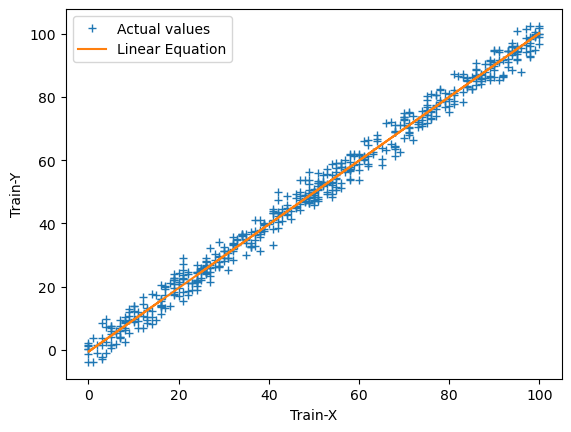

In [7]:
#calling the model to fit the data. Nothing to be done
lr = 0.0001  # Learning Rate
itrs = 30  # No. of iterations
model = LinearRegression()
Q0, Q1, losses,r2s = model.train(x_train, y_train, lr, itrs)

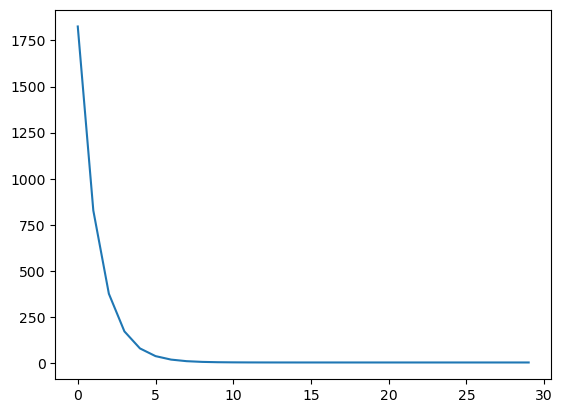

In [8]:
# Ploting the loss. Nothing to be done
plt.plot(losses)
plt.show()

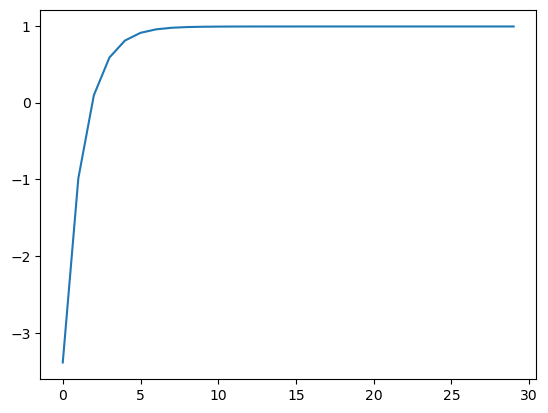

In [9]:
# Ploting the R2 score. Nothing to be done
plt.plot(r2s)
plt.show()

## performance on test data

In [10]:
y_pred = model.forward_propogation(x_test)

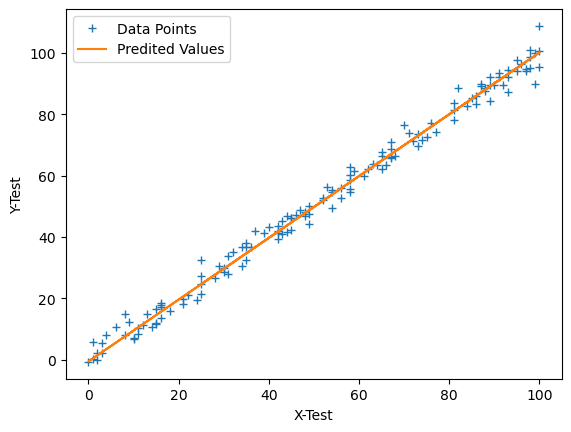

In [11]:
plt.plot(x_test, y_test, "+", label="Data Points")
plt.plot(x_test, y_pred, label="Predited Values")
plt.xlabel("X-Test")
plt.ylabel("Y-Test")
plt.legend()
plt.show()